# Experiment 03 — PdO on HfO₂: initial DoE study

Single consolidated notebook for the **first** space-filling design of experiments for
**PdO on HfO₂** (no data yet — we are at the design stage). It merges the earlier
`experiment03_hfo2_sobol_design.ipynb` (Sobol draft + method exploration) and
`experiment03_hfo2_doe_design.ipynb` (LHS+SA final) into one consistent study:

1. **Factor configuration** — bounds, resolutions, fabrication constraints.
2. **Candidate samplers** — Sobol, LHS, optimized LHS, and the conditional column-swap
   optimizers (greedy and simulated annealing).
3. **What the metrics measure** — a 2-D picture of discrepancy vs minimum pairwise distance.
4. **Direct comparison** — *all* candidate methods (including **LHS+greedy** and **LHS+SA**)
   on a single 23-condition batch, evaluated **as fabricated**.
5. **Sequential batches** — the same methods over a realistic 5-batch campaign.
6. **The chosen design** (LHS+SA) → **7. diagnostics** → **8. extensibility** → **9. export**.

**Why HfO₂ changes the bounds.** PdO on HfO₂ decomposes at ≥ ~510 °C (vs ~695 °C on Al₂O₃), so
both oxidation and vacuum-annealing temperatures are capped < 500 °C. Deposition temperature is
pinned at 425 °C, and oxidation pressure is restricted to the two practical setpoints.

**Factors (9 swept + 1 pinned):**

| # | Factor | Range | Resolution |
|---|---|---|---|
| 1 | Dep Power (W) | 2 → 40 | 1 W |
| 2 | O₂ Flow (sccm) | {0} ∪ 0.3 → 20 | 0.1 sccm |
| 3 | Dep Press (mTorr) | 2 → 10 | 0.1 mTorr |
| 4 | Ox Temp (°C) | 200 → 500 | 5 °C |
| 5 | Ox Press (atm) | {0.01, 0.02} | 2 levels |
| 6 | Ox Time (min) | 0 → 120 | 0.1 min |
| 7 | Vac Ann Temp (°C) | 25 → 500 | 5 °C |
| 8 | Vac Ann Time (min) | 0 → 120 | 0.1 min |
| 9 | Dep Thickness (nm) | 2 → 6 | 0.1 nm |
| 10 | Dep Temp (°C) | **pinned 425** | — |

Design size: **23 conditions × 3 replicates = 69 rows**. Outputs → `output/previous_studies/experiment03_hfo2_doe_design/`.

*Related:* the step-by-step build-it-yourself walkthrough of the conditional optimizer lives in
[`../tutorial/lhs_sa_build_it_yourself.ipynb`](../tutorial/lhs_sa_build_it_yourself.ipynb); the
original exploratory notebooks are archived in `../temp/`.

In [2]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import qmc
from scipy.spatial.distance import pdist, cdist
import warnings; warnings.filterwarnings('ignore')

REPO_ROOT = '/data/zhq7531/IDEAL/DMREF/repository_dmref'
os.chdir(REPO_ROOT)
OUT_DIR = 'output/previous_studies/experiment03_hfo2_doe_design'
os.makedirs(OUT_DIR, exist_ok=True)
sns.set_theme(style='whitegrid')

GLOBAL_SEED, N_CONDITIONS, NUM_REPLICATES, DEP_TEMP_FIXED = 20, 23, 3, 425.0
print('Outputs ->', OUT_DIR)

Outputs -> output/previous_studies/experiment03_hfo2_doe_design


## 1. Factor configuration

`HFO2_CONFIG` defines the 9 swept factors (Dep Temp is appended later as a pinned constant).
`map_parameter` turns a unit-cube coordinate into a physical value, snapping to the tool
resolution (`step`), honoring the discrete *0 sccm* O₂ option (`gap`), and the 2 discrete Ox Press
levels. `normalise_for_metrics` does the inverse for quality scoring (physical → [0,1], discrete
levels → evenly spaced), so we can measure a design *as it will actually be fabricated*.

In [3]:
HFO2_CONFIG = {
    'Dep Power (W)':      {'min': 2.0,   'max': 40.0,  'step': 1.0},
    'O2 Flow (sccm)':     {'gap_prob': 0.10, 'gap_val': 0.0, 'min': 0.3, 'max': 20.0, 'step': 0.1},
    'Dep Press (mTorr)':  {'min': 2.0,   'max': 10.0,  'step': 0.1},
    'Ox Temp (°C)':       {'min': 200.0, 'max': 500.0, 'step': 5.0},
    'Ox Press (atm)':     [0.01, 0.02],
    'Ox Time (min)':      {'min': 0.0,   'max': 120.0, 'step': 0.1},
    'Vac Ann Temp (°C)':  {'min': 25.0,  'max': 500.0, 'step': 5.0},
    'Vac Ann Time (min)': {'min': 0.0,   'max': 120.0, 'step': 0.1},
    'Dep Thickness (nm)': {'min': 2.0,   'max': 6.0,   'step': 0.1},
}
FACTORS = list(HFO2_CONFIG.keys()); d = len(FACTORS)

def map_parameter(u, s):
    if isinstance(s, list):                                   # discrete levels (Ox Press)
        return s[min(int(u * len(s)), len(s) - 1)]
    if s.get('gap_prob', 0) > 0 and u < s['gap_prob']:        # discrete gap value (O2 = 0 sccm)
        return s['gap_val']
    if 'gap_prob' in s and s['gap_prob'] > 0:
        u = (u - s['gap_prob']) / (1 - s['gap_prob'])
    val = s['min'] + u * (s['max'] - s['min'])
    return round(round(val / s['step']) * s['step'], 4) if 'step' in s else round(val, 4)

def normalise_for_metrics(df_in, config):
    M = df_in[[c for c in df_in.columns if c in config]].astype(float).copy()
    for c in M.columns:
        s = config[c]
        if isinstance(s, list):
            uniq = sorted(set(s)); M[c] = M[c].map({v: (i/(len(uniq)-1) if len(uniq) > 1 else 0.0)
                                                    for i, v in enumerate(uniq)})
        else:
            M[c] = (M[c] - s['min']) / (s['max'] - s['min'])
    return np.clip(M.values, 0.0, 1.0)

def to_physical(U):
    return pd.DataFrame([[map_parameter(U[r, i], HFO2_CONFIG[FACTORS[i]]) for i in range(d)]
                         for r in range(len(U))], columns=FACTORS)
print(f'{d} swept factors + Dep Temp pinned at {DEP_TEMP_FIXED:g} °C')

9 swept factors + Dep Temp pinned at 425 °C


## 2. Candidate samplers

Four families of space-filling generators compete for the design:

* **Sobol (scrambled)** — a low-discrepancy sequence; extends by simply continuing the sequence.
* **Plain LHS** — a Latin Hypercube: uniform 1-D marginals but no joint optimization.
* **Optimized LHS** (`optimization='random-cd'`) — LHS post-optimized to minimize its own
  centered-L2 discrepancy. This is also the starting design for the two optimizers below.
* **Column-swap optimizers** — starting from an optimized LHS, repeatedly **swap two values
  within one column** (which keeps the design a valid LHS) and score the *cumulative* design
  `[fixed; new]`:
  * **LHS + greedy** — accept a swap only if it lowers the discrepancy (pure hill-climb; can
    stall on a plateau).
  * **LHS + SA** — simulated annealing: sometimes accept a worse swap early on (high
    temperature) to escape local minima, then cool to a greedy finish.

The key feature of both optimizers is the **conditional objective**: pass the already-fabricated
runs as `fixed` and the search places the **new** batch to fill their gaps, holding the old
points in place. For the initial batch `fixed` is empty, so it reduces to a plain optimized LHS.
One function therefore generates the first design *and* every future extension.

In [4]:
def optimized_lhs(n, dim, seed):
    """Discrepancy-optimized Latin Hypercube (scipy random-cd) — the optimizers' starting design."""
    return qmc.LatinHypercube(d=dim, optimization='random-cd', seed=seed).random(n)

def _swap(P, col, a, b):
    P[[a, b], col] = P[[b, a], col]            # within-column swap -> stays a valid LHS

def conditional_greedy_lhs(fixed, n_new, dim, seed, n_iter=12000):
    """LHS + greedy hill-climb: same moves/objective as the SA version below, but accepts a swap
    only when it lowers the discrepancy of [fixed; new] (i.e. T = 0 throughout)."""
    rng = np.random.default_rng(seed)
    P = optimized_lhs(n_new, dim, seed)
    score = lambda: qmc.discrepancy(np.vstack([fixed, P]) if len(fixed) else P)
    best = score()
    for _ in range(n_iter):
        c = rng.integers(dim); a, b = rng.choice(n_new, 2, replace=False)
        _swap(P, c, a, b); cand = score()
        if cand < best:
            best = cand
        else:
            _swap(P, c, a, b)                  # no improvement -> revert
    return P

def conditional_sa_lhs(fixed, n_new, dim, seed, n_iter=12000, T_end=1e-3):
    """LHS + simulated annealing minimizing discrepancy of [fixed; new], `fixed` frozen.
    `fixed` may be an empty (0, dim) array for the initial batch. Returns the new batch (unit cube)."""
    rng = np.random.default_rng(seed)
    P = optimized_lhs(n_new, dim, seed)
    score = lambda: qmc.discrepancy(np.vstack([fixed, P]) if len(fixed) else P)
    cur = best = score(); best_P = P.copy()
    ups = []                                   # auto-scale start temperature to a typical uphill move
    for _ in range(200):
        c = rng.integers(dim); a, b = rng.choice(n_new, 2, replace=False)
        _swap(P, c, a, b); delta = score() - cur; _swap(P, c, a, b)
        if delta > 0: ups.append(delta)
    T = T0 = float(np.mean(ups)) if ups else 1e-3
    alpha = T_end ** (1.0 / n_iter)
    for _ in range(n_iter):
        c = rng.integers(dim); a, b = rng.choice(n_new, 2, replace=False)
        _swap(P, c, a, b); cand = score(); delta = cand - cur
        if delta < 0 or rng.random() < np.exp(-delta / max(T, 1e-12)):
            cur = cand
            if cur < best: best, best_P = cur, P.copy()
        else:
            _swap(P, c, a, b)                  # reject -> revert
        T *= alpha                             # cool
    return best_P

## 3. What the metrics measure (a 2-D picture)

The comparisons below score every design on three numbers, which reward different things —
a design can be best on one and much worse on another. The 2-D demo (16 points, easy to
eyeball) makes the first two concrete.

**Discrepancy (centered L2) — a *global uniformity* score.** Conceptually: for every axis-aligned
sub-box of the unit square, compare the *fraction of points inside* to the *box's area*.
Discrepancy aggregates that mismatch over all sub-boxes (and over every lower-dimensional
projection). It answers **"does every region — and every factor's marginal — get its fair share
of runs?"** Lower = more evenly spread over the whole space. *This is the space-filling metric.*

**Minimum pairwise distance (maximin) — a *closest-pair* score.** It looks only at the single
nearest pair of points and measures how far apart they are. It answers **"are any two runs nearly
redundant / on top of each other?"** Higher = no clustering. But it is *blind to empty regions* —
you can leave a big hole in the middle and still have a large minimum distance.

**Max |off-diagonal correlation| — a *factor independence* score** (used in the full comparisons,
not in this 2-D demo). The largest absolute Pearson correlation between any two factor columns.
Correlated factors confound each other's effects in the downstream regression/GP; we treat
|r| < 0.3 as the safe zone. Lower = more independent factors.

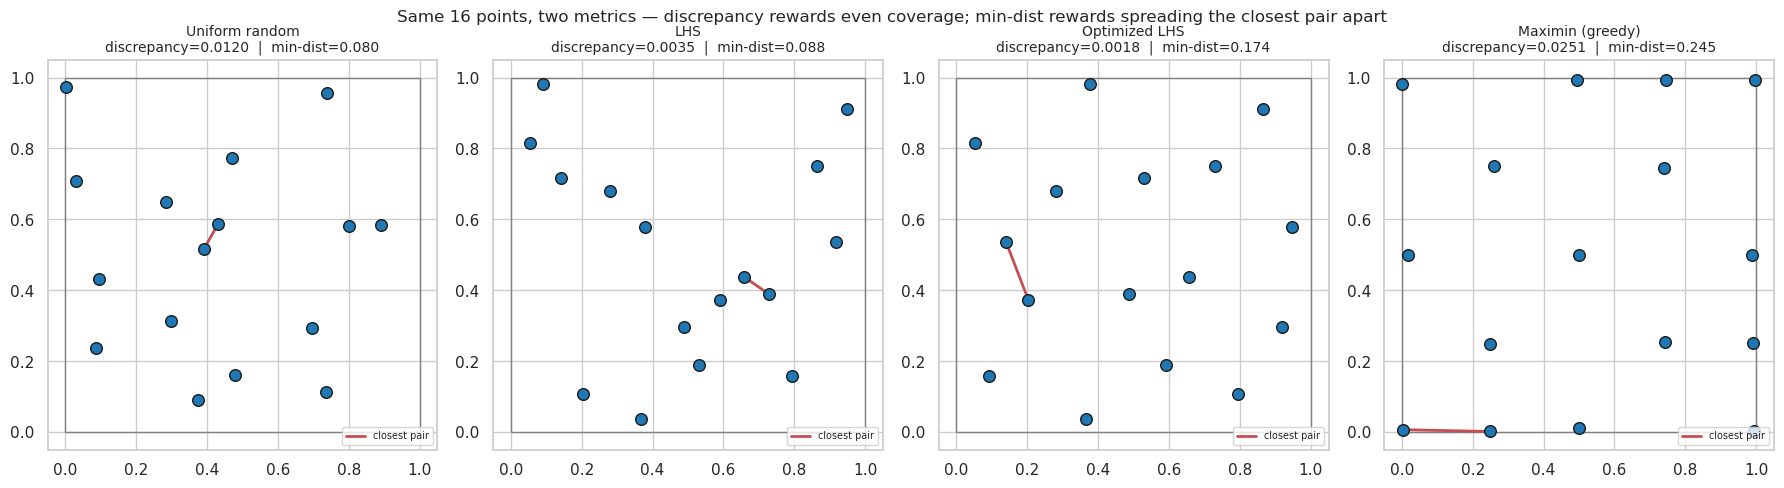

In [5]:
n_demo = 16
rng_d = np.random.default_rng(3)

P_rand = rng_d.random((n_demo, 2))
P_lhs  = qmc.LatinHypercube(d=2, seed=1).random(n_demo)
P_olhs = qmc.LatinHypercube(d=2, optimization='random-cd', seed=1).random(n_demo)
# greedy maximin: each new point maximizes its min-distance to all chosen points
_chosen = [np.array([0.5, 0.5])]
for _ in range(n_demo - 1):
    c = rng_d.random((4000, 2))
    _chosen.append(c[cdist(c, np.array(_chosen)).min(axis=1).argmax()])
P_mm = np.array(_chosen)

demos = [('Uniform random', P_rand), ('LHS', P_lhs),
         ('Optimized LHS', P_olhs), ('Maximin (greedy)', P_mm)]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.7))
for ax, (name, P) in zip(axes, demos):
    disc_v = qmc.discrepancy(P)
    # find and highlight the closest pair (what min-dist measures)
    D = cdist(P, P); np.fill_diagonal(D, np.inf)
    i, j = np.unravel_index(D.argmin(), D.shape); md_v = D[i, j]
    ax.scatter(P[:, 0], P[:, 1], s=70, color='#1f77b4', edgecolor='k', zorder=3)
    ax.plot(P[[i, j], 0], P[[i, j], 1], 'r-', lw=2, zorder=2, label='closest pair')
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, ec='gray'))
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05); ax.set_aspect('equal')
    ax.set_title(f'{name}\ndiscrepancy={disc_v:.4f}  |  min-dist={md_v:.3f}', fontsize=10)
    ax.legend(loc='lower right', fontsize=7)
fig.suptitle('Same 16 points, two metrics — discrepancy rewards even coverage; '
             'min-dist rewards spreading the closest pair apart', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'metric_meaning_2d_demo.png'), dpi=200, bbox_inches='tight')
plt.show()

**What the picture shows.** *Optimized LHS* spreads points evenly across the square and across
both axes → **low discrepancy**, with a respectable closest-pair gap. *Maximin* pushes points
toward the **edges and corners** (like same-charge particles repelling to the walls): this gives
the **largest closest-pair distance**, but it leaves the interior and the marginal projections
unevenly covered → **high discrepancy**.

**Is one more important?** For a space-filling DoE whose job is to **explore the response and fit
a surrogate across the whole domain, discrepancy is the primary metric** — you want every region
and every factor-projection represented, no blind spots. Minimum distance is a **secondary
guard**: it stops you from wasting runs on near-duplicates and, for a second batch, from placing a
new run on top of an already-fabricated one. The right move is therefore to **optimize coverage
(low discrepancy) subject to healthy spacing**, which is exactly what the discrepancy-objective
optimizers (optimized LHS, LHS+greedy, LHS+SA) do — and factor independence (low |r|) comes along
with good joint coverage.

## 4. Direct comparison — one batch, all candidate methods

All six candidates generate the same-size batch (23 conditions) and are evaluated **as
fabricated**: each design is mapped to physical units — snapping to the resolution grid
*including the 2-level Ox Press* — and re-normalized before scoring, so every method lives under
the identical real-world constraint and the comparison is fair.

* **Uniform random** — the naive baseline.
* **Sobol (scrambled)** — the low-discrepancy sequence (what the first draft of this study used).
* **Plain LHS** — uniform marginals, no joint optimization.
* **Optimized LHS (random-cd)** — the usual "best" classical space-filling design.
* **LHS + greedy** — optimized-LHS start + greedy column-swap hill-climb on discrepancy.
* **LHS + SA** — same moves with simulated-annealing acceptance.

Each method is scored as **mean ± 1 std over 8 seeds** on the three metrics of §3.

In [6]:
EMPTY = np.empty((0, d))

def _round_norm(U):                          # unit-cube design -> fabricated -> normalized [0,1]
    return normalise_for_metrics(to_physical(U), HFO2_CONFIG)

def _maxoff(P):
    C = np.corrcoef(P.T); np.fill_diagonal(C, 0.0); return np.abs(C).max()

def fab_metrics(U):
    """(discrepancy, max |off-diag r|, min pairwise dist) of a unit-cube design, as fabricated."""
    P = _round_norm(U)
    return qmc.discrepancy(P), _maxoff(P), pdist(P).min()

CMP_SEEDS, CMP_ITER = 8, 5000

# one fixed color per method, reused by every comparison chart in this notebook
METHOD_COLORS = {
    'Uniform random':            '#7f7f7f',
    'Sobol (scrambled)':         '#1f77b4',
    'Plain LHS':                 '#2ca02c',
    'Optimized LHS (random-cd)': '#9467bd',
    'LHS + greedy':              '#ff7f0e',
    'LHS + SA':                  '#d62728',
}
samplers_cmp = {
    'Uniform random':            lambda s: np.random.default_rng(s).random((N_CONDITIONS, d)),
    'Sobol (scrambled)':         lambda s: qmc.Sobol(d=d, scramble=True, seed=s).random(N_CONDITIONS),
    'Plain LHS':                 lambda s: qmc.LatinHypercube(d=d, seed=s).random(N_CONDITIONS),
    'Optimized LHS (random-cd)': lambda s: optimized_lhs(N_CONDITIONS, d, s),
    'LHS + greedy':              lambda s: conditional_greedy_lhs(EMPTY, N_CONDITIONS, d, s, n_iter=CMP_ITER),
    'LHS + SA':                  lambda s: conditional_sa_lhs(EMPTY, N_CONDITIONS, d, s, n_iter=CMP_ITER),
}

direct = {}
rows = []
for name, gen in samplers_cmp.items():
    vals = np.array([fab_metrics(gen(s)) for s in range(CMP_SEEDS)])   # (seeds, 3)
    direct[name] = vals
    rows.append({'method': name,
                 'discrepancy':        round(float(vals[:, 0].mean()), 5),
                 'discrepancy_std':    round(float(vals[:, 0].std()), 5),
                 'max_offdiag_r':      round(float(vals[:, 1].mean()), 3),
                 'max_offdiag_r_std':  round(float(vals[:, 1].std()), 3),
                 'min_pairwise_dist':      round(float(vals[:, 2].mean()), 4),
                 'min_pairwise_dist_std':  round(float(vals[:, 2].std()), 4)})
direct_tbl = pd.DataFrame(rows)
direct_tbl.to_excel(os.path.join(OUT_DIR, 'direct_method_comparison.xlsx'), index=False)
print(f'One batch of {N_CONDITIONS} conditions, evaluated as fabricated; mean over {CMP_SEEDS} seeds.')
direct_tbl

One batch of 23 conditions, evaluated as fabricated; mean over 8 seeds.


,method,discrepancy,discrepancy_std,max_offdiag_r,max_offdiag_r_std,min_pairwise_dist,min_pairwise_dist_std
0,Uniform random,0.47430,0.07753,0.505,0.047,0.5216,0.1002
1,Sobol (scrambled),0.31337,0.01125,0.451,0.115,0.5911,0.1134
2,Plain LHS,0.32441,0.00970,0.486,0.064,0.5236,0.0820
3,Optimized LHS (random-cd),0.25718,0.00304,0.169,0.052,0.7888,0.0603
4,LHS + greedy,0.25381,0.00284,0.160,0.024,0.7968,0.0492
5,LHS + SA,0.25586,0.00236,0.175,0.037,0.7934,0.0358


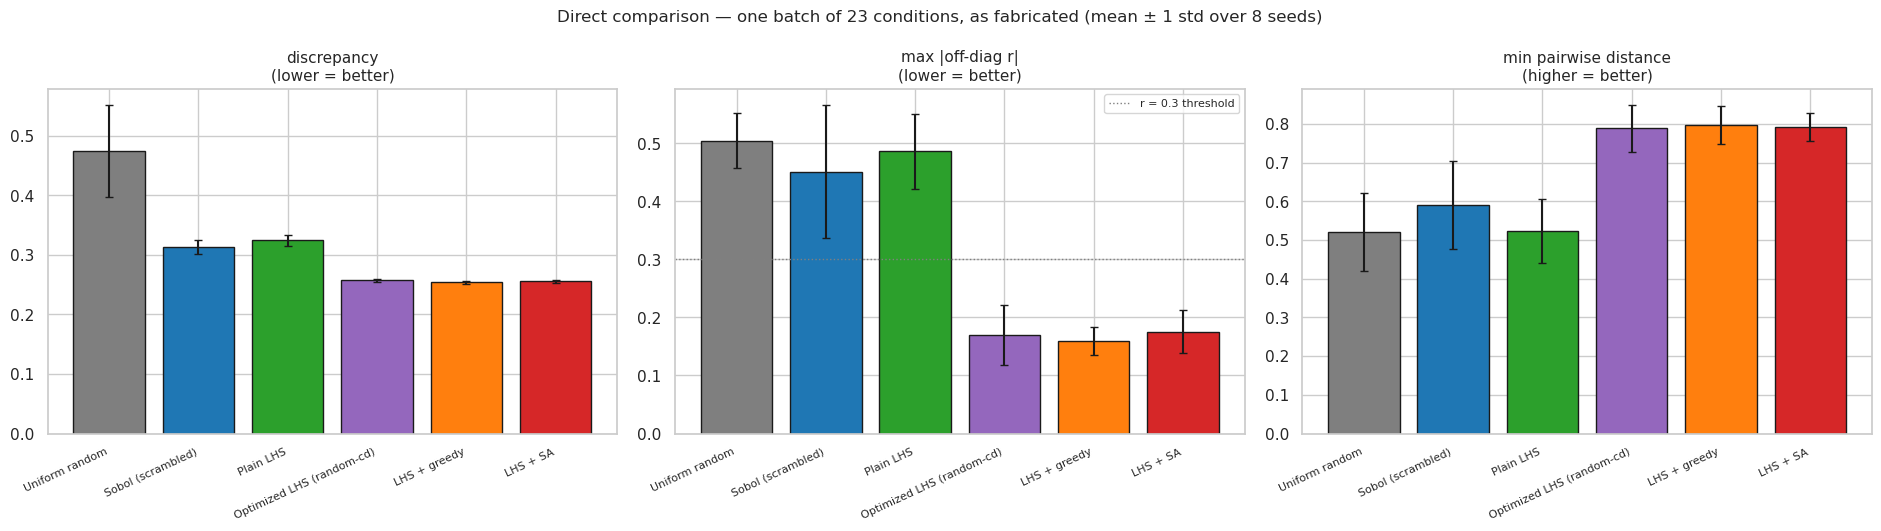

In [7]:
names = list(samplers_cmp)
panels = [(0, 'discrepancy', 'lower = better'),
          (1, 'max |off-diag r|', 'lower = better'),
          (2, 'min pairwise distance', 'higher = better')]
fig, axes = plt.subplots(1, 3, figsize=(19, 5.4))
for ax, (qi, ylab, better) in zip(axes, panels):
    mu = [direct[m][:, qi].mean() for m in names]
    sd = [direct[m][:, qi].std()  for m in names]
    ax.bar(range(len(names)), mu, yerr=sd, capsize=3,
           color=[METHOD_COLORS[m] for m in names], edgecolor='k')
    if qi == 1:
        ax.axhline(0.3, ls=':', color='gray', lw=1, label='r = 0.3 threshold'); ax.legend(fontsize=8)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=25, ha='right', fontsize=8)
    ax.set_title(f'{ylab}\n({better})', fontsize=11)
fig.suptitle(f'Direct comparison — one batch of {N_CONDITIONS} conditions, as fabricated '
             f'(mean ± 1 std over {CMP_SEEDS} seeds)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'direct_method_comparison.png'), dpi=180, bbox_inches='tight')
plt.show()

**Reading the direct comparison.** The three discrepancy-optimized designs — optimized LHS,
LHS+greedy, LHS+SA — cluster at the low end on discrepancy (≈ 0.254–0.257 vs 0.313 for Sobol,
0.324 for plain LHS, 0.474 for random), and they dominate just as clearly on factor independence
(max |r| ≈ 0.16–0.18, the only methods under the 0.3 threshold) and on spacing (min pairwise
distance ≈ 0.79 vs ≤ 0.59 for everything else). LHS+greedy and LHS+SA edge out plain optimized
LHS, but are **statistically tied with each other** at this size — the differences are well
within the seed-to-seed spread. A single batch, however, is only half the story: the design must
also **extend** cleanly when later batches are added, which is what §5 tests.

## 5. Sequential batches — the same methods over a 5-batch campaign

We compare four sequential-batch strategies over **5 batches of 23 conditions** (up to 115
cumulative points), and — crucially — evaluate **every method *as fabricated***, exactly as in §4:

* **Sobol (fab)** — continue one Sobol sequence each batch.
* **Plain LHS (fab)** — a fresh plain Latin Hypercube each batch (no joint optimization).
* **LHS+greedy (fab)** — `conditional_greedy_lhs`, freezing all previously-fabricated runs.
* **LHS+SA (fab)** — `conditional_sa_lhs`, freezing all previously-fabricated runs.

Each point is the **mean over 4 random seeds** with **±1 std error bars** — the bars show the
seed-to-seed spread, so a single good design (like the exported one in §6) can land below its
line, especially for the noisy worst-pair correlation metric.

In [9]:
NB_BATCHES, SEEDS = 5, 4
ns = [N_CONDITIONS * (k + 1) for k in range(NB_BATCHES)]
methods = ('Sobol', 'Plain LHS', 'LHS+optimized', 'LHS+SA')
M = {m: {q: np.zeros((SEEDS, NB_BATCHES)) for q in ('disc', 'maxr', 'mind')} for m in methods}

def _rec(store, si, k, Pnorm):
    store['disc'][si, k] = qmc.discrepancy(Pnorm)
    store['maxr'][si, k] = _maxoff(Pnorm)
    store['mind'][si, k] = pdist(Pnorm).min()

for si, seed in enumerate(range(SEEDS)):
    eng = qmc.Sobol(d=d, scramble=True, seed=seed)
    sob = np.empty((0, d)); plhs = np.empty((0, d)); grd = np.empty((0, d)); sa = np.empty((0, d))
    for k in range(NB_BATCHES):
        sob  = np.vstack([sob,  eng.random(N_CONDITIONS)])
        plhs = np.vstack([plhs, qmc.LatinHypercube(d=d, seed=seed * 100 + k).random(N_CONDITIONS)])
        grd  = np.vstack([grd,  conditional_greedy_lhs(grd, N_CONDITIONS, d, seed * 10 + k, n_iter=5000)])
        sa   = np.vstack([sa,   conditional_sa_lhs(sa, N_CONDITIONS, d, seed * 10 + k, n_iter=5000)])
        _rec(M['Sobol'], si, k, _round_norm(sob))
        _rec(M['Plain LHS'], si, k, _round_norm(plhs))
        _rec(M['LHS+optimized'], si, k, _round_norm(grd))
        _rec(M['LHS+SA'], si, k, _round_norm(sa))

cmp_tbl = pd.DataFrame({'cum_conditions': ns})
for m in methods:
    cmp_tbl[f'{m} disc'] = M[m]['disc'].mean(0).round(4)
    cmp_tbl[f'{m} maxr'] = M[m]['maxr'].mean(0).round(3)
cmp_tbl.to_excel(os.path.join(OUT_DIR, 'method_comparison.xlsx'), index=False)

styles = {'Sobol':      ('o-', METHOD_COLORS['Sobol (scrambled)']),
          'Plain LHS':  ('^-', METHOD_COLORS['Plain LHS']),
          'LHS+optimized': ('D-', METHOD_COLORS['LHS+optimized']),
          'LHS+SA':     ('s-', METHOD_COLORS['LHS + SA'])}
panels = [('disc', 'discrepancy', 'lower = better'),
          ('maxr', 'max |off-diag r|', 'lower = better'),
          ('mind', 'min pairwise distance', 'higher = better')]
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
for a, (q, ylab, better) in zip(ax, panels):
    for m, (ls, c) in styles.items():
        a.errorbar(ns, M[m][q].mean(0), yerr=M[m][q].std(0), fmt=ls, color=c, label=m,
                   capsize=3, markersize=6, elinewidth=1, capthick=1)
    if q == 'maxr': a.axhline(0.3, ls=':', color='gray', lw=1, label='r = 0.3 threshold')
    a.set_xlabel('cumulative conditions'); a.set_ylabel(ylab); a.set_title(f'{ylab}\n({better})')
    a.legend(fontsize=8); a.set_xticks(ns)
fig.suptitle('5 sequential batches, all evaluated as fabricated (2-level Ox Press) — '
             'mean ± 1 std over 4 seeds', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'method_comparison.png'), dpi=180, bbox_inches='tight')
plt.show()
cmp_tbl

KeyError: 'LHS+optimized'

**Decision.** Under the identical fabrication constraint, the two conditional column-swap
optimizers dominate Sobol and plain LHS on every metric at every batch: lowest discrepancy,
decisively lowest correlation (under the 0.3 confounding threshold throughout, while Sobol and
plain LHS start at 0.42–0.46 and never catch up at these sizes), and the largest minimum
spacing. All methods' discrepancies share the same raised floor set by the 2-level Ox Press (a
hard process constraint, identical for every method), so it does not change the ranking. Sobol's
theoretical low-discrepancy edge only appears at n ≈ 400+ — far beyond a realistic campaign —
and it never matches the conditional optimizers on factor independence, which is what most helps
the downstream GP/BO separate effects.

Between the two optimizers, cumulative discrepancy is a dead heat (0.1795 vs 0.1792 at 115
conditions), and **LHS+SA** holds the lower worst-pair correlation at most cumulative sizes
(0.049 vs 0.064 at 115). Since SA costs the same per iteration and its annealed acceptance
additionally protects against plateau stalls on harder conditional fills, **we use LHS+SA for
the sampling.**

## 6. The chosen design (23 conditions)

Generate the initial batch with `conditional_sa_lhs` (empty `fixed`), map to physical units, pin
Dep Temp at 425 °C, and expand to 3 replicates.

In [ ]:
U = conditional_sa_lhs(np.empty((0, d)), N_CONDITIONS, d, GLOBAL_SEED, n_iter=12000)
design = to_physical(U)
design['Dep Temp (°C)'] = DEP_TEMP_FIXED
design.insert(0, 'Base_Run_ID', range(1, N_CONDITIONS + 1))
design['Batch'] = 'Batch 1'

design_full = design.loc[design.index.repeat(NUM_REPLICATES)].reset_index(drop=True)
design_full.insert(1, 'Replicate', design_full.groupby('Base_Run_ID').cumcount() + 1)

disc_design = qmc.discrepancy(normalise_for_metrics(design, HFO2_CONFIG))
print(f'{N_CONDITIONS} conditions x {NUM_REPLICATES} replicates = {len(design_full)} rows | '
      f'fabricated discrepancy = {disc_design:.4f}')
design.drop(columns='Batch')

23 conditions x 3 replicates = 69 rows | fabricated discrepancy = 0.2525


,Base_Run_ID,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Dep Temp (°C)
0,1,7.0,4.6,8.2,330.0,0.02,101.6,325.0,32.9,2.6,425.0
1,2,36.0,9.7,4.3,330.0,0.01,4.0,440.0,53.1,2.7,425.0
2,3,24.0,9.0,9.7,200.0,0.02,9.3,250.0,17.2,4.1,425.0
3,4,37.0,16.6,6.3,355.0,0.01,88.3,75.0,9.9,2.5,425.0
4,5,23.0,7.0,9.4,435.0,0.01,95.7,410.0,98.9,3.4,425.0
5,6,21.0,0.9,3.3,435.0,0.02,73.7,205.0,49.0,2.2,425.0
6,7,10.0,8.0,2.9,280.0,0.01,56.6,430.0,12.4,5.8,425.0
7,8,27.0,17.5,2.0,475.0,0.01,61.4,300.0,36.6,3.9,425.0
8,9,4.0,15.5,5.9,390.0,0.02,43.6,390.0,112.4,3.0,425.0
9,10,19.0,3.0,6.6,260.0,0.01,71.7,90.0,30.8,5.4,425.0


## 7. Design diagnostics

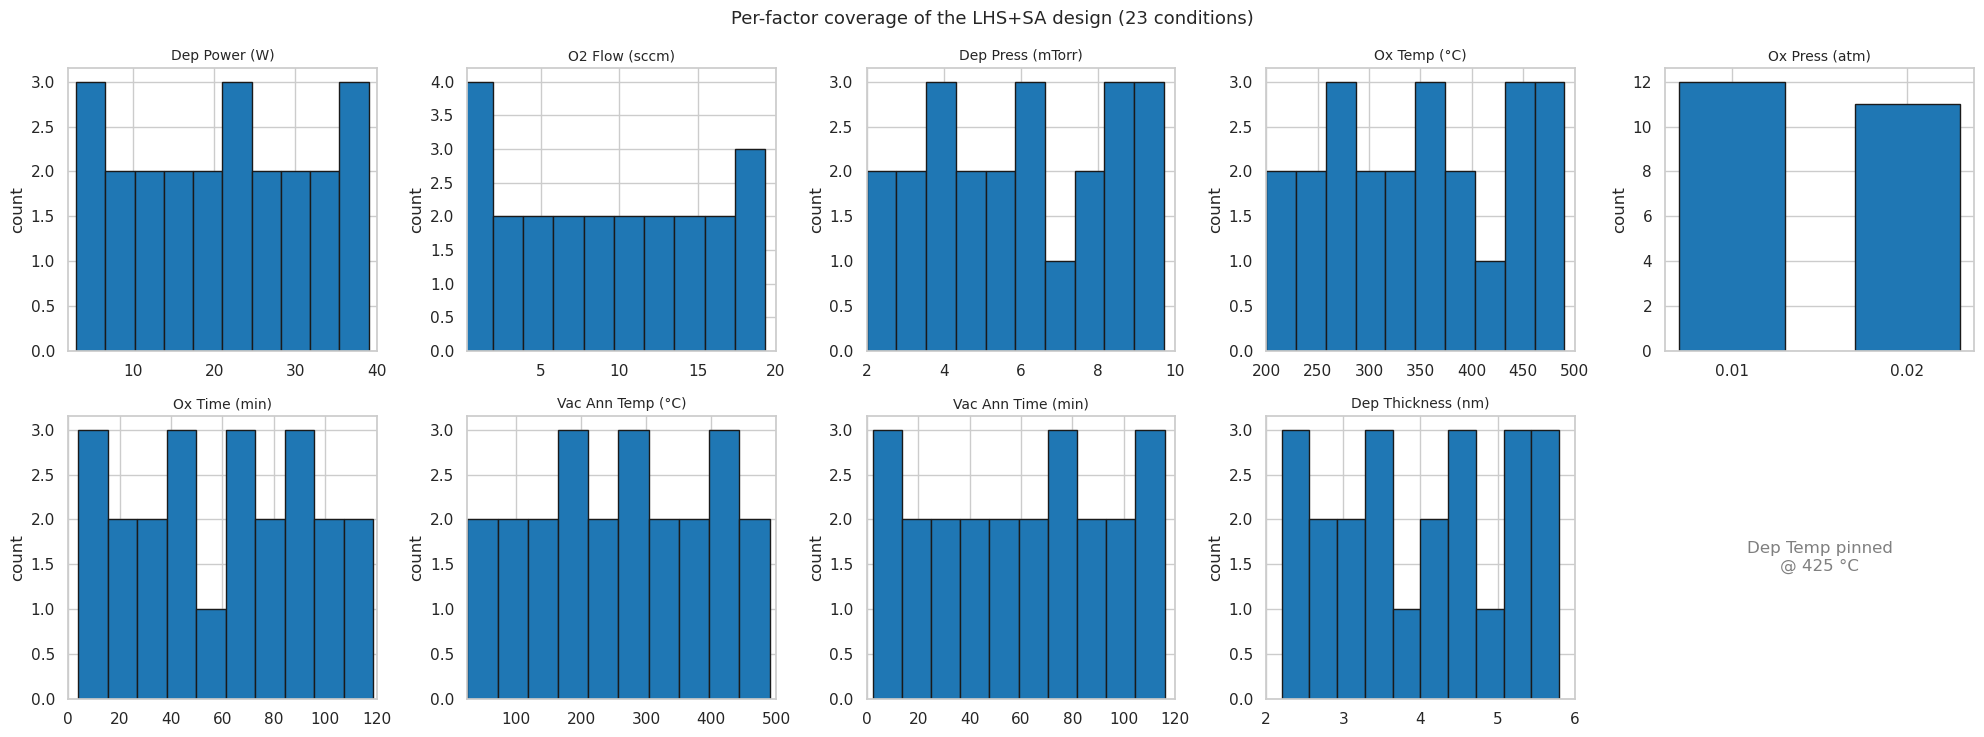

In [ ]:
# Per-factor coverage (each factor should fill its range; discrete factors shown as level counts)
fig, axes = plt.subplots(2, 5, figsize=(20, 7.5))
for ax, f in zip(axes.flat, FACTORS):
    s = HFO2_CONFIG[f]
    if isinstance(s, list):
        lv = sorted(s); ax.bar([str(x) for x in lv], [int((design[f] == x).sum()) for x in lv],
                               color='#1f77b4', edgecolor='k', width=0.6)
    else:
        ax.hist(design[f], bins=10, color='#1f77b4', edgecolor='k'); ax.set_xlim(s['min'], s['max'])
    ax.set_title(f, fontsize=10); ax.set_ylabel('count')
axes.flat[9].axis('off')
axes.flat[9].text(0.5, 0.5, f'Dep Temp pinned\n@ {DEP_TEMP_FIXED:g} °C', ha='center', va='center',
                  fontsize=12, color='gray')
fig.suptitle(f'Per-factor coverage of the LHS+SA design ({N_CONDITIONS} conditions)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'factor_distributions.png'), dpi=200, bbox_inches='tight')
plt.show()

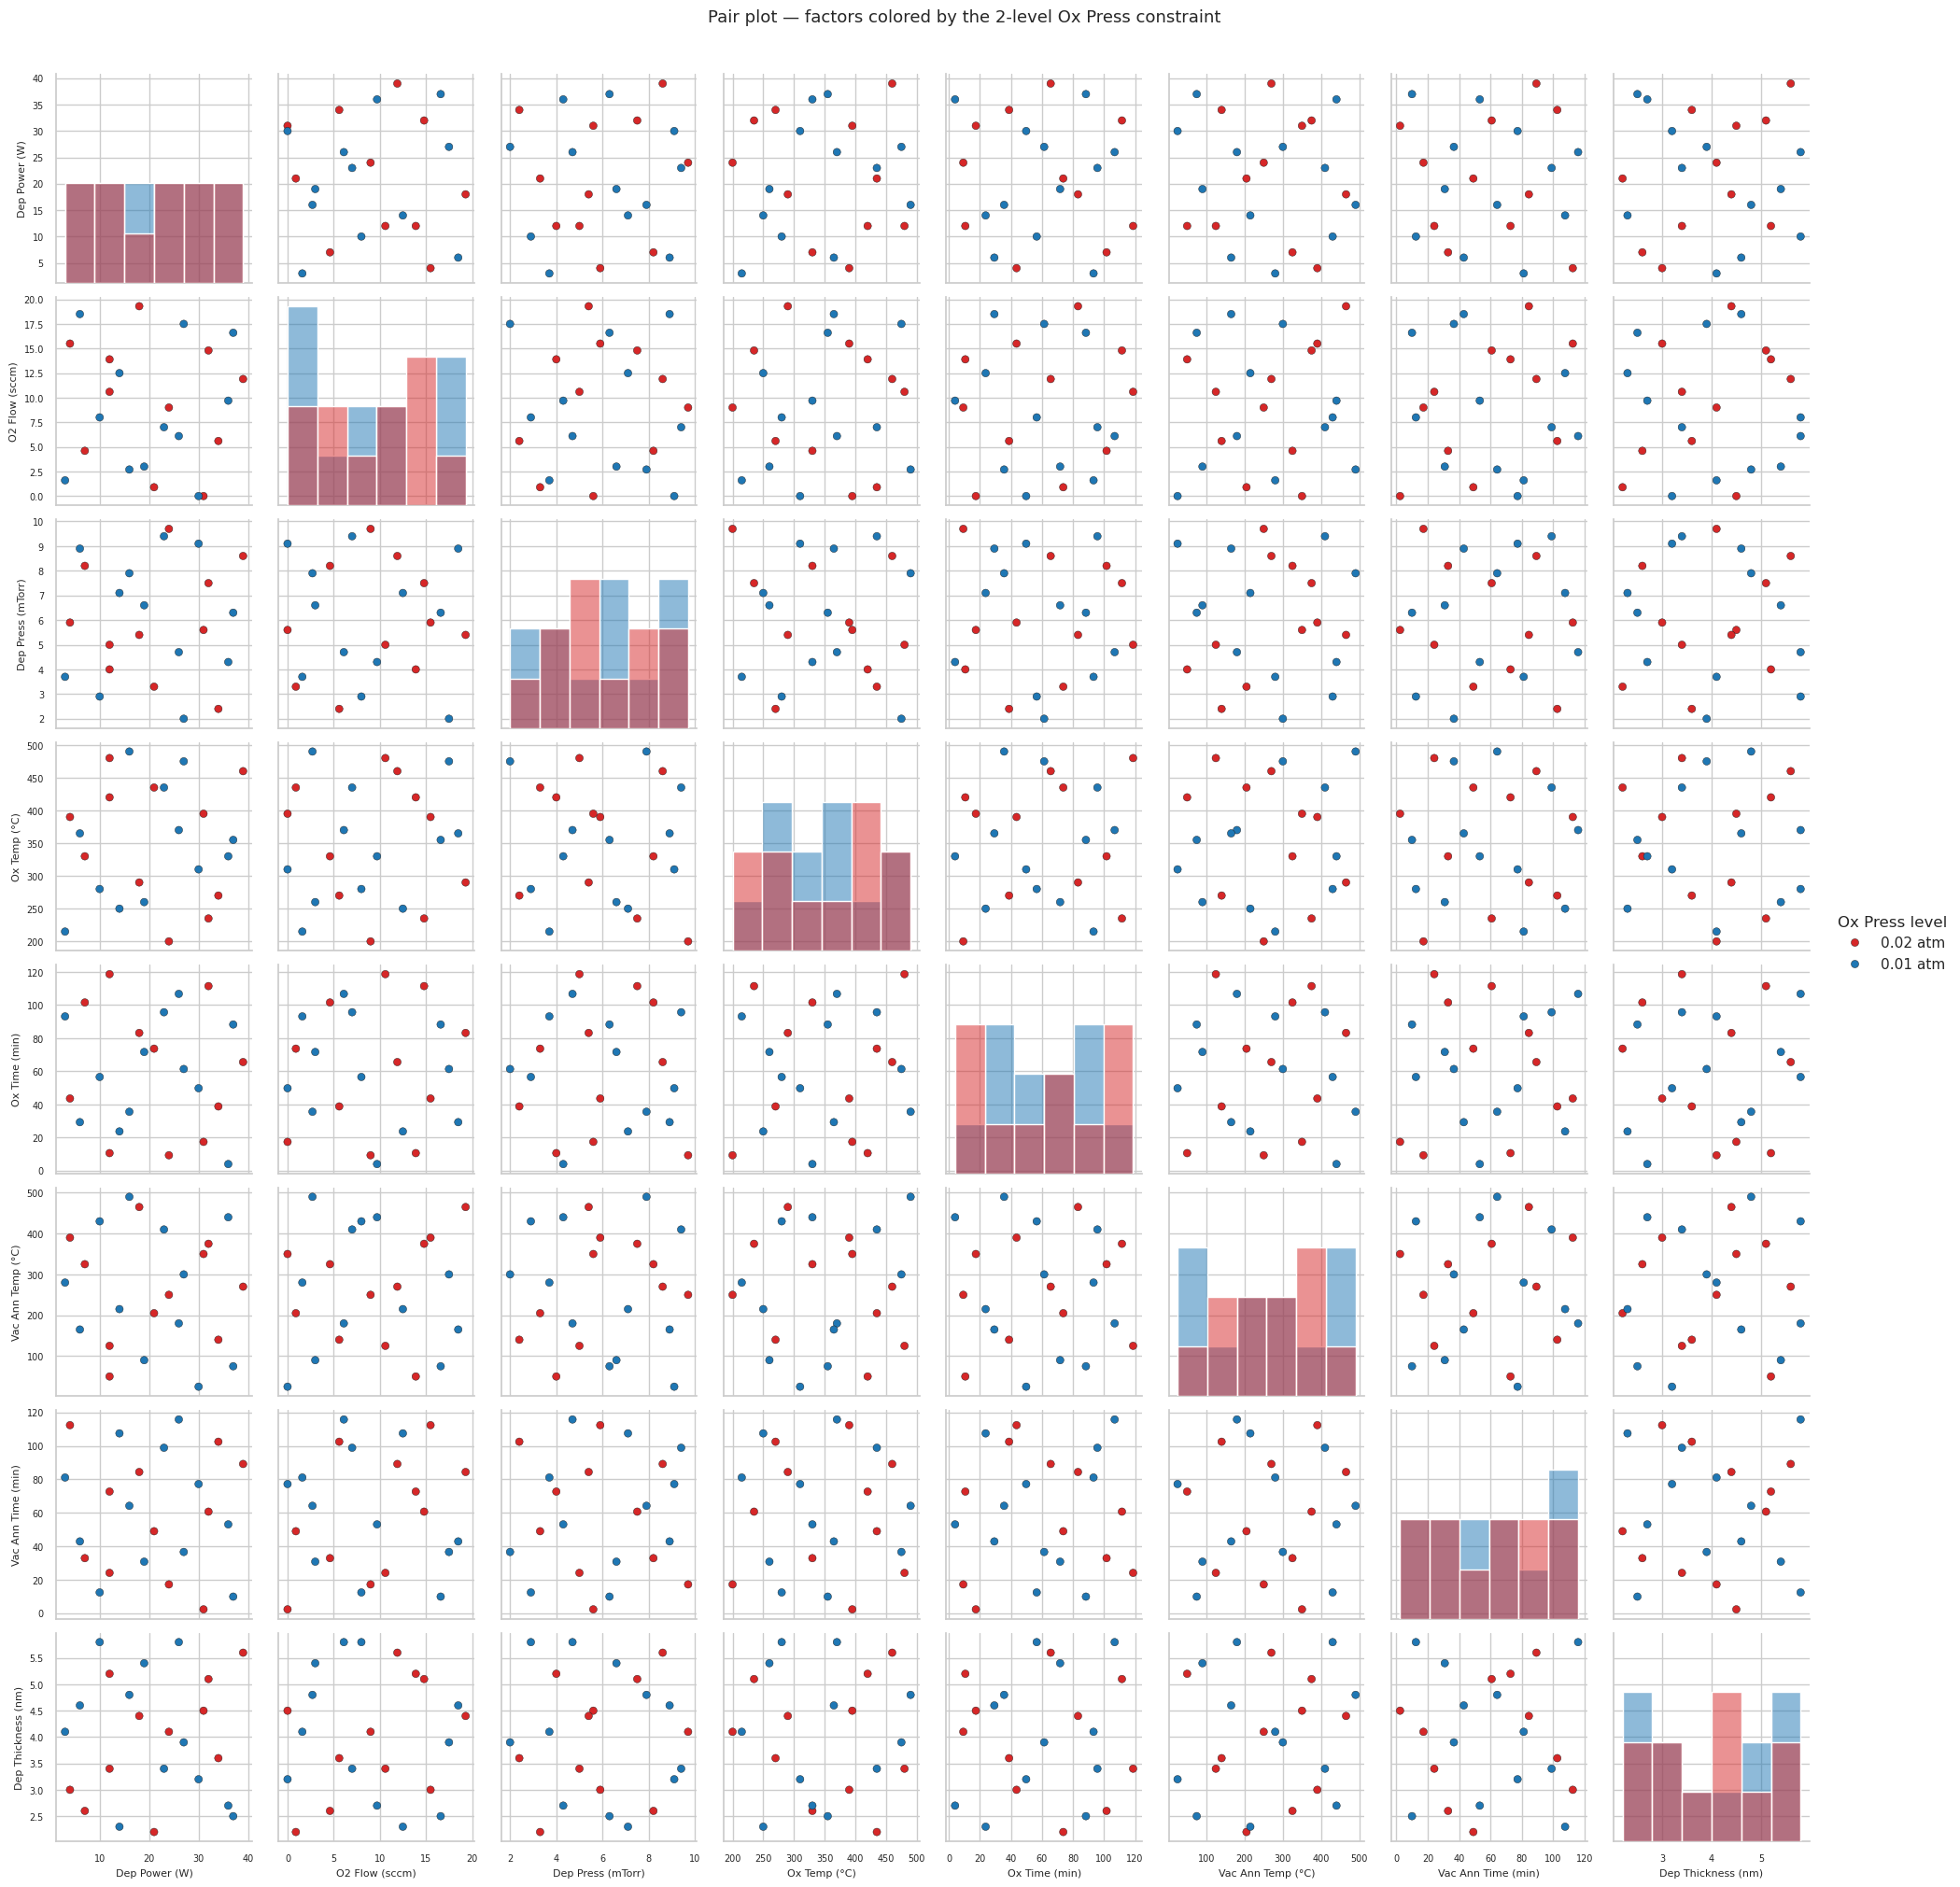

Ox Press split: {'0.01 atm': 12, '0.02 atm': 11}


In [ ]:
# Pair plot colored by the 2-level Ox Press constraint
dfp = design.copy()
dfp['Ox Press level'] = dfp['Ox Press (atm)'].round(2).map({0.01: '0.01 atm', 0.02: '0.02 atm'})
other = [f for f in FACTORS if f != 'Ox Press (atm)']
g = sns.pairplot(dfp, vars=other, hue='Ox Press level', corner=False, diag_kind='hist',
                 palette={'0.01 atm': '#1f77b4', '0.02 atm': '#d62728'},
                 plot_kws=dict(s=34, edgecolor='k', linewidth=0.3))
g.fig.suptitle('Pair plot — factors colored by the 2-level Ox Press constraint', y=1.02, fontsize=13)
for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(labelsize=7); ax.xaxis.label.set_size(8); ax.yaxis.label.set_size(8)
g.savefig(os.path.join(OUT_DIR, 'pairplot_oxpress.png'), dpi=170, bbox_inches='tight')
plt.show()
print('Ox Press split:', dfp['Ox Press level'].value_counts().to_dict())

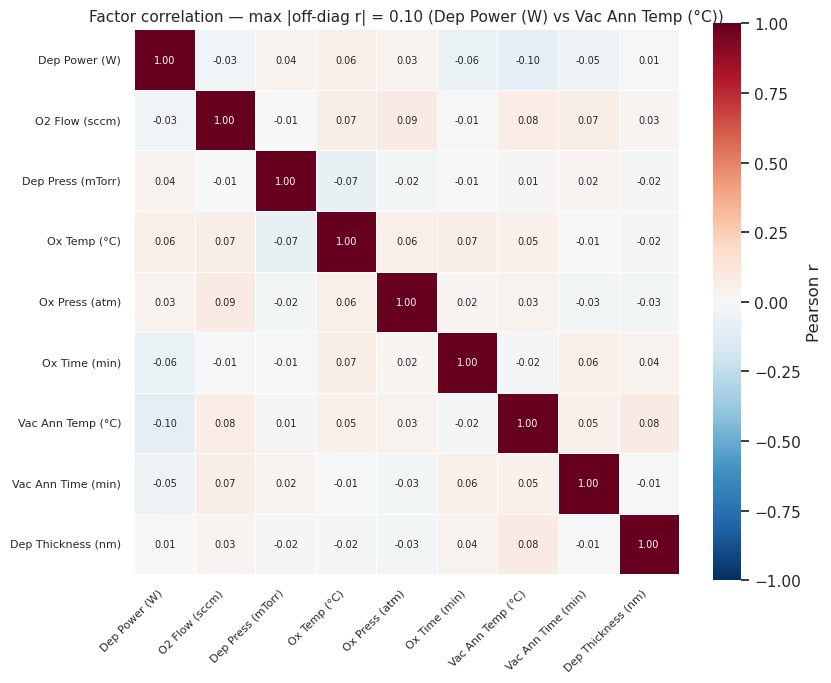

max |off-diagonal correlation| = 0.098


In [ ]:
# Correlation matrix (binary Ox Press included) — factor independence check
corr = design[FACTORS].corr()
off = corr.where(~np.eye(len(corr), dtype=bool)); mx = off.abs().max().max()
ip, jp = np.unravel_index(np.nanargmax(off.abs().values), off.shape)
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, annot_kws={'size': 7}, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title(f'Factor correlation — max |off-diag r| = {mx:.2f} ({FACTORS[ip]} vs {FACTORS[jp]})',
             fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(fontsize=8); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'correlation_matrix.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f'max |off-diagonal correlation| = {mx:.3f}')

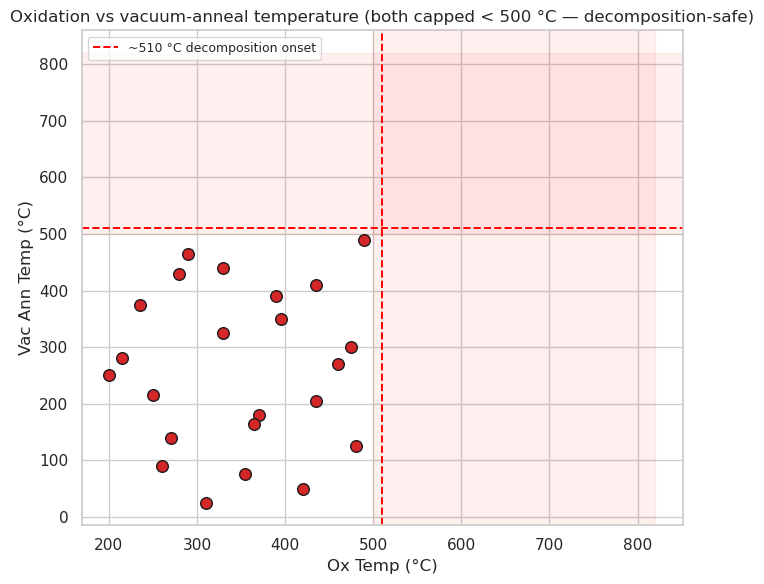

In [ ]:
# Decomposition-safe temperature plane: both temperatures must stay < 500 °C
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(design['Ox Temp (°C)'], design['Vac Ann Temp (°C)'], c='#d62728', s=70,
           edgecolor='k', zorder=3)
ax.axvspan(500, 820, color='red', alpha=0.06); ax.axhspan(500, 820, color='red', alpha=0.06)
ax.axvline(510, ls='--', color='red', lw=1.4, label='~510 °C decomposition onset')
ax.axhline(510, ls='--', color='red', lw=1.4)
ax.set_xlabel('Ox Temp (°C)'); ax.set_ylabel('Vac Ann Temp (°C)')
ax.set_title('Oxidation vs vacuum-anneal temperature (both capped < 500 °C — decomposition-safe)')
ax.legend(loc='upper left', fontsize=9); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'temperature_plane.png'), dpi=200, bbox_inches='tight')
plt.show()

## 8. Extensibility — adding future batches

Choosing LHS+SA does **not** lock the campaign to 23 runs. For batch 2 (then 3, …), freeze the
already-fabricated runs and call `conditional_sa_lhs` again — it fills the gaps of *all* prior
points, regardless of how they were made. The check below shows a 3-batch build reaches the same
cumulative quality as designing all 69 points at once, so nothing is lost by going incrementally.

In [ ]:
b1 = conditional_sa_lhs(np.empty((0, d)), N_CONDITIONS, d, 1, n_iter=6000)
b2 = conditional_sa_lhs(b1, N_CONDITIONS, d, 2, n_iter=6000)
b3 = conditional_sa_lhs(np.vstack([b1, b2]), N_CONDITIONS, d, 3, n_iter=6000)
fresh69 = optimized_lhs(3 * N_CONDITIONS, d, 0)
print('cumulative discrepancy (unit cube) as batches are added:')
print(f'  after batch 1 (23): {qmc.discrepancy(b1):.4f}')
print(f'  after batch 2 (46): {qmc.discrepancy(np.vstack([b1, b2])):.4f}')
print(f'  after batch 3 (69): {qmc.discrepancy(np.vstack([b1, b2, b3])):.4f}')
print(f'  [ref] fresh 69-pt optimized LHS designed at once: {qmc.discrepancy(fresh69):.4f}')

cumulative discrepancy (unit cube) as batches are added:
  after batch 1 (23): 0.0693
  after batch 2 (46): 0.0303
  after batch 3 (69): 0.0190
  [ref] fresh 69-pt optimized LHS designed at once: 0.0181


## 9. Export the fabrication design

In [ ]:
out_path = os.path.join(OUT_DIR, 'PdO_HfO2_LHS_SA_design.xlsx')
cfg_rows = []
for f, s in HFO2_CONFIG.items():
    if isinstance(s, list):
        cfg_rows.append({'factor': f, 'min': min(s), 'max': max(s), 'step': '—', 'levels': str(s)})
    else:
        cfg_rows.append({'factor': f, 'min': s['min'], 'max': s['max'], 'step': s.get('step'),
                         'levels': f"gap_val={s['gap_val']} (p={s['gap_prob']})" if s.get('gap_prob') else '—'})
cfg_rows.append({'factor': 'Dep Temp (°C)', 'min': DEP_TEMP_FIXED, 'max': DEP_TEMP_FIXED,
                 'step': '—', 'levels': 'pinned'})
prov = pd.DataFrame([
    {'property': 'design method', 'value': 'LHS + simulated annealing (min cumulative discrepancy)'},
    {'property': 'chosen over', 'value': 'uniform random, Sobol, plain LHS, optimized LHS, LHS+greedy (§4–§5)'},
    {'property': 'n_conditions', 'value': N_CONDITIONS},
    {'property': 'replicates', 'value': NUM_REPLICATES},
    {'property': 'seed', 'value': GLOBAL_SEED},
    {'property': 'fabricated discrepancy', 'value': round(float(disc_design), 4)},
    {'property': 'max |off-diag correlation|', 'value': round(float(mx), 3)},
    {'property': 'extensible', 'value': 'yes — conditional_sa_lhs(freeze fabricated runs) for later batches'},
])
with pd.ExcelWriter(out_path) as w:
    design_full.to_excel(w, sheet_name='design_full',   index=False)
    design.to_excel(w,      sheet_name='design_unique', index=False)
    pd.DataFrame(cfg_rows).to_excel(w, sheet_name='config', index=False)
    prov.to_excel(w,        sheet_name='provenance',    index=False)
print('Saved:', out_path)
design_full.head(9)

Saved: output/previous_studies/experiment03_hfo2_doe_design/PdO_HfO2_LHS_SA_design.xlsx


,Base_Run_ID,Replicate,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Dep Temp (°C),Batch
0,1,1,7.0,4.6,8.2,330.0,0.02,101.6,325.0,32.9,2.6,425.0,Batch 1
1,1,2,7.0,4.6,8.2,330.0,0.02,101.6,325.0,32.9,2.6,425.0,Batch 1
2,1,3,7.0,4.6,8.2,330.0,0.02,101.6,325.0,32.9,2.6,425.0,Batch 1
3,2,1,36.0,9.7,4.3,330.0,0.01,4.0,440.0,53.1,2.7,425.0,Batch 1
4,2,2,36.0,9.7,4.3,330.0,0.01,4.0,440.0,53.1,2.7,425.0,Batch 1
5,2,3,36.0,9.7,4.3,330.0,0.01,4.0,440.0,53.1,2.7,425.0,Batch 1
6,3,1,24.0,9.0,9.7,200.0,0.02,9.3,250.0,17.2,4.1,425.0,Batch 1
7,3,2,24.0,9.0,9.7,200.0,0.02,9.3,250.0,17.2,4.1,425.0,Batch 1
8,3,3,24.0,9.0,9.7,200.0,0.02,9.3,250.0,17.2,4.1,425.0,Batch 1


## Output files

All under `output/previous_studies/experiment03_hfo2_doe_design/`:

* **`PdO_HfO2_LHS_SA_design.xlsx`** — the fabrication design (69-row run sheet + 23 unique conditions + config + provenance).
* `direct_method_comparison.png` / `direct_method_comparison.xlsx` — §4 single-batch comparison of
  all six methods (incl. LHS+greedy and LHS+SA), as fabricated.
* `method_comparison.png` / `method_comparison.xlsx` — §5 five-batch sequential comparison
  (Sobol vs plain LHS vs LHS+greedy vs LHS+SA), justifying the choice.
* `metric_meaning_2d_demo.png` — §3 2-D illustration of discrepancy vs minimum pairwise distance.
* `factor_distributions.png`, `pairplot_oxpress.png`, `correlation_matrix.png`,
  `temperature_plane.png` — §7 design diagnostics.

**Next step (after fabrication returns data):** mirror `experiment02_pdo_analysis.ipynb` —
preliminary analysis, ANOVA, replicate CV, regression validation, factor effects, then the
multi-objective Bayesian optimization loop (the reusable GP + qLogNEHVI code lives in
`repository_dmref/utils/mobo.py`). Extend with batch 2 via `conditional_sa_lhs`, freezing the
fabricated runs. For a hands-on walkthrough of the optimizer itself, see
[`../tutorial/lhs_sa_build_it_yourself.ipynb`](../tutorial/lhs_sa_build_it_yourself.ipynb).